In [1]:
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

In [2]:
def compute_ister_score(dataset_df, user_info_df):
    merged_df = pd.merge(dataset_df, user_info_df, left_on="user_id", right_on="user_id")
    item_attr_interactions_df = merged_df[["item_id", "attr"]]
    item_attr_dist = item_attr_interactions_df.groupby(["item_id", "attr"]).size()
    attr_dist = item_attr_interactions_df.groupby("attr").size()
    igi_score = item_attr_dist / attr_dist
    
    # compute i_ster score
    ister_scores = dict()
    for iid in dataset_df["item_id"].unique():
        if 0 not in igi_score.loc[iid] or 1 not in igi_score.loc[iid]:
            ister_scores[iid] = 0
        else:
            diff = igi_score.loc[iid][0] - igi_score.loc[iid][1]
            ister_scores[iid] = diff / max(igi_score.loc[iid][0], igi_score.loc[iid][1])
    
    return ister_scores

def measure_stereotypicality(user_stereotypicality, attr):
    if attr == 0:
        return user_stereotypicality
    else:
        return -user_stereotypicality

def _apply_dp(dataset_df, item_pool, privacy_budget):
    prob_keep = 1 / (np.exp(privacy_budget) + 1) + (np.exp(privacy_budget) - 1) / (np.exp(privacy_budget) + 1)

    new_dataset = []
    for user_id, dataset_user_df in dataset_df.groupby("user_id"):
        n_keep = np.ceil(len(dataset_user_df) * prob_keep).astype(int)
        keep_data = dataset_user_df.loc[np.random.choice(dataset_user_df.index, replace=False, size=n_keep)]
        new_dataset.extend(keep_data.to_records(index=False).tolist())

        neg_items = set(item_pool).difference(dataset_user_df["item_id"].unique())
        added_iids = np.random.choice(list(neg_items), replace=False, size=min(len(dataset_user_df) - n_keep, len(neg_items)))
        add_data = [(user_id, item_id, -1) for item_id in added_iids]
        new_dataset.extend(add_data)

    return pd.DataFrame.from_records(new_dataset, columns=["user_id", "item_id", "rating"])

In [3]:
dataset_df = pd.read_csv("bx/bx.dataset.rating", sep="\t", header=None, names=["user_id", "item_id", "rating"])

users_df = pd.read_csv("bx/bx.userlist", sep="\t")
users_df.columns = ["user_id", "attr"]

ister_scores = compute_ister_score(dataset_df, users_df)
dataset_df["i_ster"] = dataset_df["item_id"].map(ister_scores)

uster_scores = dataset_df.groupby("user_id")["i_ster"].mean()
users_df["u_ster"] = users_df["user_id"].map(uster_scores)

users_df["abs_u_ster"] = users_df.apply(lambda r: measure_stereotypicality(r["u_ster"], r["attr"]), axis=1)

# user analysis

In [21]:
df = dataset_df.merge(users_df)[["user_id", "item_id", "rating", "i_ster", "attr"]]

df["is_stereo"] = (((df["i_ster"] > 0) & (df["attr"] == 0)) | ((df["i_ster"] < 0) & (df["attr"] == 1))| (df["i_ster"] == 0)).astype(int)
df.groupby("user_id")["is_stereo"].mean().mean()

0.6700663978162739

In [22]:
df

,user_id,item_id,rating,i_ster,attr,is_stereo
0,0,1511,8,0.571877,0,1
1,0,943,8,-0.221408,0,0
2,0,1030,9,0.746506,0,1
3,0,1194,9,-0.404606,0,0
4,0,336,7,0.131161,0,1
...,...,...,...,...,...,...
65106,3970,5212,7,-0.610704,1,1
65107,3970,4525,5,-0.134898,1,1
65108,3970,4403,7,0.357815,1,0
65109,3970,5528,7,-0.221408,1,1


In [4]:
users_df.groupby("attr")["u_ster"].mean()

attr
0    0.211162
1   -0.143006
Name: u_ster, dtype: float64

attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

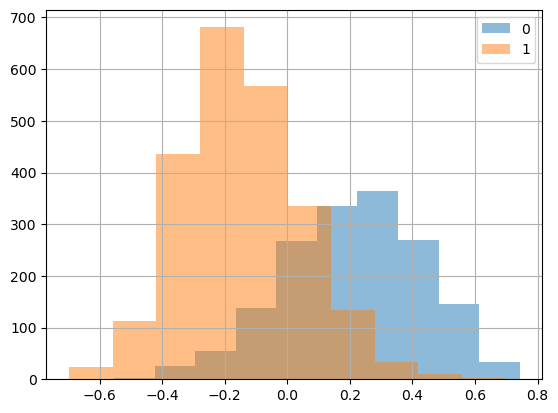

In [5]:
users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [6]:
users_df["attr"].value_counts() / len(users_df)

1    0.588265
0    0.411735
Name: attr, dtype: float64

In [7]:
df = dataset_df.merge(users_df, left_on="user_id", right_on="user_id")
x = (df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).sum()
y = (df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).sum()

print((x+y) / df["user_id"].nunique())
df["is_stereo"] = (((df["attr"] == 0) & (df["i_ster"] > 0)) | ((df["attr"] == 1) & (df["i_ster"] < 0))).astype(int)
df.groupby("user_id")["is_stereo"].mean().mean()

9.942835557794007


0.6202226696578391

In [8]:
users_df["abs_u_ster"].mean()

0.1710679036456942

In [9]:
u_ster0 = users_df[users_df["attr"] == 0]["u_ster"].values
u_ster1 = users_df[users_df["attr"] == 1]["u_ster"].values
wasserstein_distance(u_ster0, u_ster1)

0.3541673274798397

## select only stereotypical users

0.8287461773700305
0.7782534246575342
0.7990430622009569
attr
0    380.678971
1   -399.075586
Name: u_ster, dtype: float64
1    0.572959
0    0.427041
Name: attr, dtype: float64
0.7239618943434067
0.6114553990610329
0.24574678763703786


attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

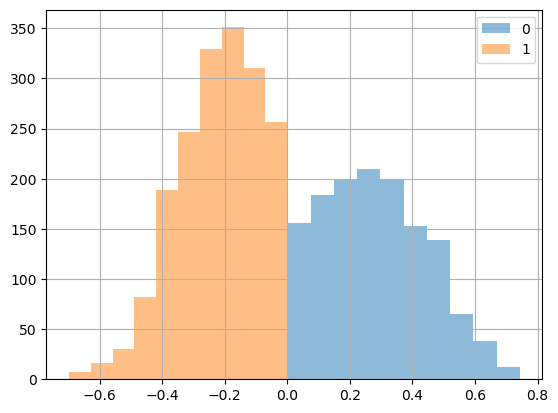

In [4]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] > 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] < 0)]

print(len(users0_df) / (users_df["attr"] == 0).sum())
print(len(users1_df) / (users_df["attr"] == 1).sum())

stereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(stereotypical_users_df) / len(users_df))

print(stereotypical_users_df.groupby("attr")["u_ster"].sum())
print(stereotypical_users_df["attr"].value_counts() / len(stereotypical_users_df))

df = dataset_df.merge(stereotypical_users_df, left_on="user_id", right_on="user_id")
print((df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).mean())
print((df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).mean())

print(stereotypical_users_df["abs_u_ster"].mean())
stereotypical_users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [5]:
print(len(stereotypical_users_df) / len(users_df))
stereotypical_users_df["abs_u_ster"].mean()

0.7990430622009569


0.24574678763703786

In [12]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] < 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] > 0)]

antistereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(antistereotypical_users_df) / len(users_df))
print(antistereotypical_users_df.groupby("attr")["u_ster"].mean())
print(antistereotypical_users_df["abs_u_ster"].mean())

0.20095693779904306
attr
0   -0.126535
1    0.125510
Name: u_ster, dtype: float64
-0.12586956365321983


In [13]:
stereotypical_users_df = users_df[users_df["abs_u_ster"] > 0.1]

In [14]:
stereotypical_users = stereotypical_users_df["user_id"].values
stereotypical_df = df[df["user_id"].isin(stereotypical_users)]

user_map = {old: new for new, old in enumerate(stereotypical_df["user_id"].unique())}
item_map = {old: new for new, old in enumerate(stereotypical_df["item_id"].unique())}

stereotypical_df["user_id"] = stereotypical_df["user_id"].map(user_map)
stereotypical_df["item_id"] = stereotypical_df["item_id"].map(item_map)
stereotypical_df.rename(columns={"user_id": "user_id:token", "item_id": "item_id:token", "rating": "rating:token", "attr": "attr:token"}, inplace=True)

stereotypical_df[["user_id:token", "item_id:token", "rating:token"]].to_csv("bx.dataset.rating", sep="\t", index=False, header=False)
stereotypical_df.drop_duplicates(subset=["user_id:token", "attr:token"]).to_csv("bx.userlist", sep="\t", index=False)

C:\Users\pmuellner\AppData\Local\Temp\ipykernel_18100\779387538.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stereotypical_df["user_id"] = stereotypical_df["user_id"].map(user_map)
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_18100\779387538.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stereotypical_df["item_id"] = stereotypical_df["item_id"].map(item_map)
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_18100\779387538.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

# item analysis

In [6]:
items0 = dict()
items1 = dict()
for iid, score in ister_scores.items():
    if score > 0:
        items0[iid] = score
    elif score < 0:
        items1[iid] = score

print(len(items0) / len(ister_scores), len(items1) / len(ister_scores))
print(np.mean(list(items0.values())), np.mean(list(items1.values())))

0.4623807841752031 0.4480748851995761
0.42657406515695073 -0.47399231167425926


# other

In [16]:
def get_uster_per_beta(df, beta):
    u_sters = []
    for user_id, group_df in df.groupby("user_id"):
        attr = group_df["attr"].values[0]
        if attr == 0:
            sorted_df = group_df.sort_values(by="i_ster", ascending=True)
        else:
            sorted_df = group_df.sort_values(by="i_ster", ascending=False)

        n_keep = int(len(group_df) * beta)
        keep_df = sorted_df[:n_keep][["user_id", "item_id", "rating"]]
        dp_df = group_df.loc[list(set(group_df.index).difference(keep_df.index))]

        item_pool = set(df["item_id"].unique()).difference(group_df["item_id"].values)
        dp_df = _apply_dp(dp_df[["user_id", "item_id", "rating"]], item_pool, privacy_budget=0.1)

        total_df = pd.concat([keep_df, dp_df])
        u_ster = total_df["item_id"].map(ister_scores).mean()
        u_sters.append(measure_stereotypicality(u_ster, attr))
    return np.mean(u_sters)

betas = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
usters = [get_uster_per_beta(df, b) for b in betas]



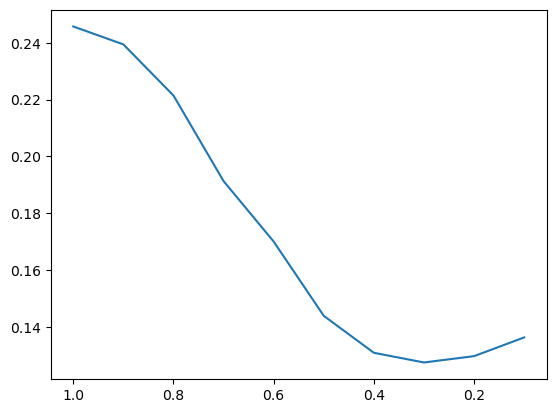

In [17]:
plt.plot(betas, usters)
plt.gca().invert_xaxis()

In [18]:
usters

[0.24574678763703786,
 0.2394392545301654,
 0.22145455139296166,
 0.19133868126281392,
 0.1700622536512401,
 0.1439324808510783,
 0.1309314011918999,
 0.12751816086555195,
 0.12974694864541267,
 0.13633607435667897]